
## What it now does
- creates a realistic synthetic daily demand dataset
- builds richer lag + calendar features
- evaluates a gradient-boosting model with:
  - holdout metrics
  - baseline comparisons
  - rolling time-series backtests
- forecasts the next 14 days with **uncertainty bands** (p10 / p50 / p90)
- computes a **risk-aware transfer recommendation** using safety stock
- outputs an operations table ready for app integration

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 5)

CONFIG = {
    "seed": 42,
    "days": 540,
    "test_size": 30,
    "forecast_horizon": 14,
    "rolling_folds": 4,
    "rolling_window": 30,
    "min_train_size": 240,
    "service_level_z": 1.28,  # ~90% cycle service level
    "use_real_data": True,
    "malaysia_donations_url": "https://storage.data.gov.my/healthcare/blood_donations.csv",
    "blood_type_filter": "O",
}

print(CONFIG)

{'seed': 42, 'days': 540, 'test_size': 30, 'forecast_horizon': 14, 'rolling_folds': 4, 'rolling_window': 30, 'min_train_size': 240, 'service_level_z': 1.28, 'use_real_data': True, 'malaysia_donations_url': 'https://storage.data.gov.my/healthcare/blood_donations.csv', 'blood_type_filter': 'O'}


## 1) Load real data (with synthetic fallback)

We first try to load a real public dataset: Malaysia daily blood donations by blood group.

Pipeline logic:
- load the public CSV
- optionally filter to one blood group (`blood_type_filter`)
- aggregate to daily totals and map to `demand_units`
- fallback to synthetic generation if download/schema checks fail

In [2]:
def build_synthetic_data(days: int) -> pd.DataFrame:
    dates = pd.date_range("2024-01-01", periods=days, freq="D")

    t = np.arange(days)
    weekly = 6 * np.sin(2 * np.pi * t / 7)
    monthly_like = 3 * np.sin(2 * np.pi * t / 30)
    trend = 0.01 * t
    noise = np.random.normal(0, 2.2, size=days)

    base = 28 + weekly + monthly_like + trend + noise

    spikes = np.zeros(days)
    spike_idx = np.random.choice(np.arange(20, days - 20), size=14, replace=False)
    spikes[spike_idx] = np.random.uniform(8, 18, size=len(spike_idx))

    demand = np.maximum(5, base + spikes).round(0)
    return pd.DataFrame({"date": dates, "demand_units": demand.astype(int)})


def load_real_daily_donations(url: str, blood_type_filter: str | None = None) -> pd.DataFrame:
    raw = pd.read_csv(url)
    raw.columns = [c.strip().lower() for c in raw.columns]

    required_cols = {"date", "donations"}
    if not required_cols.issubset(set(raw.columns)):
        raise ValueError(f"Missing required columns: {required_cols - set(raw.columns)}")

    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["donations"] = pd.to_numeric(raw["donations"], errors="coerce")
    clean = raw.dropna(subset=["date", "donations"]).copy()

    if blood_type_filter and "blood_type" in clean.columns:
        filtered = clean[clean["blood_type"].astype(str).str.upper() == blood_type_filter.upper()]
        if len(filtered) > 0:
            clean = filtered

    daily = (
        clean.groupby("date", as_index=False)["donations"]
        .sum()
        .sort_values("date")
        .rename(columns={"donations": "demand_units"})
    )

    daily["demand_units"] = daily["demand_units"].clip(lower=0).round().astype(int)
    return daily


required_min_rows = (
    CONFIG["min_train_size"]
    + CONFIG["test_size"]
    + CONFIG["forecast_horizon"]
    + 35
)

source_name = "synthetic"
if CONFIG["use_real_data"]:
    try:
        df = load_real_daily_donations(
            CONFIG["malaysia_donations_url"],
            CONFIG.get("blood_type_filter"),
        )
        if len(df) < required_min_rows:
            raise ValueError(
                f"Real dataset too short after filtering: need >= {required_min_rows}, got {len(df)}"
            )
        source_name = "real_malaysia_donations"
    except Exception as exc:
        print(f"Real data load failed ({exc}). Falling back to synthetic data.")
        df = build_synthetic_data(CONFIG["days"])
else:
    df = build_synthetic_data(CONFIG["days"])

print(f"Data source: {source_name}; rows: {len(df)}")
df.head()

Data source: real_malaysia_donations; rows: 7392


,date,demand_units
0,2006-01-01,194
1,2006-01-02,112
2,2006-01-03,56
3,2006-01-04,165
4,2006-01-05,193


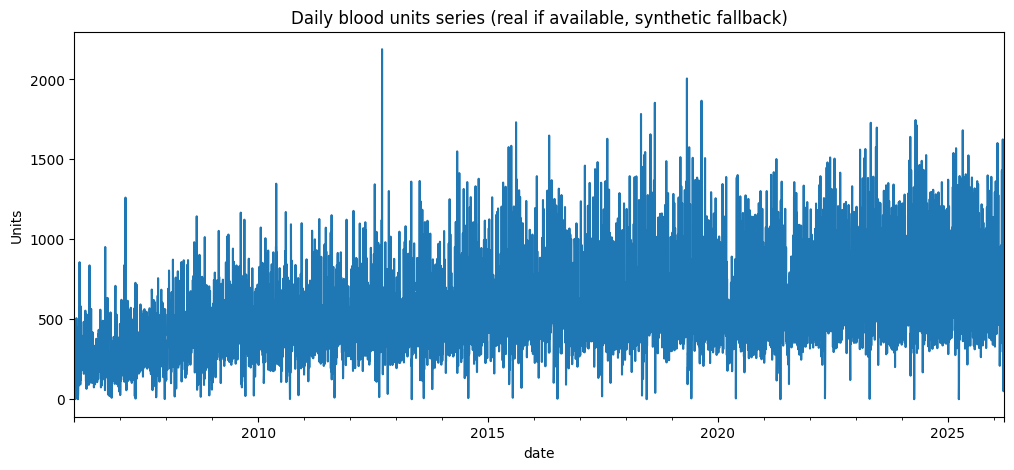

In [3]:
title = "Daily blood units series (real if available, synthetic fallback)"
df.set_index("date")["demand_units"].plot(title=title)
plt.ylabel("Units")
plt.show()

In [4]:
SUPPLEMENTARY_DATASETS = {
    "mimic_admissions": "https://physionet.org/files/mimiciii-demo/1.4/ADMISSIONS.csv?download",
    "mimic_inputevents_mv": "https://physionet.org/files/mimiciii-demo/1.4/INPUTEVENTS_MV.csv?download",
    "cdc_donor": "https://data.cdc.gov/api/views/wi5c-cscz/rows.csv?accessType=DOWNLOAD",
}

supplementary_shapes = {}
for name, url in SUPPLEMENTARY_DATASETS.items():
    try:
        tmp = pd.read_csv(url)
        supplementary_shapes[name] = tmp.shape
    except Exception as exc:
        supplementary_shapes[name] = f"load_failed: {exc}"

supplementary_shapes

{'mimic_admissions': (129, 19),
 'mimic_inputevents_mv': (13224, 31),
 'cdc_donor': (1270, 52)}

### Optional supplementary real datasets

These are useful for richer feature engineering later (not required for this core run):
- MIMIC-III demo admissions
- MIMIC-III demo input events
- CDC donor dataset

They are intentionally loaded in a guarded way so failures do not break the notebook.

## 2) Feature engineering

We build lagged and calendar-based features so forecasting becomes supervised learning.

Features used:
- lag demand: 1, 2, 3, 7, 14, 28 days
- rolling stats from history (7 and 14 days)
- day-of-week cyclical encoding (sin/cos)
- month cyclical encoding (sin/cos)
- weekend indicator
- short momentum feature (`delta_week`)

In [5]:
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()
    y = data["demand_units"]

    for lag in [1, 2, 3, 7, 14, 28]:
        data[f"lag_{lag}"] = y.shift(lag)

    data["roll_mean_7"] = y.shift(1).rolling(7).mean()
    data["roll_mean_14"] = y.shift(1).rolling(14).mean()
    data["roll_std_7"] = y.shift(1).rolling(7).std()
    data["delta_week"] = y.shift(1) - y.shift(8)

    dow = data.index.dayofweek
    month = data.index.month

    data["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    data["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    data["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
    data["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)
    data["is_weekend"] = (dow >= 5).astype(int)

    return data.dropna()


feature_df = make_features(df.set_index("date"))
feature_df.head()

,demand_units,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,roll_mean_7,roll_mean_14,roll_std_7,delta_week,dow_sin,dow_cos,month_sin,month_cos,is_weekend
date,,,,,,,,,,,,,,,,
2006-01-29,0,65.0,48.0,449.0,173.0,235.0,194.0,235.428571,274.928571,165.080644,-133.0,-0.781831,0.623490,0.0,1.000000,1
2006-01-30,16,0.0,65.0,48.0,163.0,232.0,112.0,210.714286,258.142857,187.422619,-173.0,0.000000,1.000000,0.0,1.000000,0
2006-01-31,34,16.0,0.0,65.0,428.0,507.0,56.0,189.714286,242.714286,201.375863,-147.0,0.781831,0.623490,0.0,1.000000,0
2006-02-01,116,34.0,16.0,0.0,322.0,363.0,165.0,133.428571,208.928571,177.296228,-394.0,0.974928,-0.222521,0.5,0.866025,0
2006-02-02,194,116.0,34.0,16.0,449.0,393.0,193.0,104.000000,191.285714,156.676950,-206.0,0.433884,-0.900969,0.5,0.866025,0


## 3) Train / test split

We keep the last `test_size` days as holdout and compare against naive baselines.
This lets us quantify model value over simple heuristics.

In [6]:
target = "demand_units"
feature_cols = [c for c in feature_df.columns if c != target]

test_size = CONFIG["test_size"]
train_df = feature_df.iloc[:-test_size].copy()
test_df = feature_df.iloc[-test_size:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]
X_test = test_df[feature_cols]
y_test = test_df[target]

X_train.shape, X_test.shape

((7334, 15), (30, 15))

## 4) Train model + compare baselines

We train `HistGradientBoostingRegressor` and compare against practical baselines:
- naive last value (`t-1`)
- seasonal naive (`t-7`)
- rolling 7-day mean

Then we run rolling time-series backtests for more robust evaluation.

In [7]:
def build_model(loss: str = "squared_error", quantile: float | None = None) -> HistGradientBoostingRegressor:
    kwargs = {
        "max_depth": 5,
        "learning_rate": 0.05,
        "max_iter": 300,
        "random_state": CONFIG["seed"],
        "loss": loss,
    }
    if quantile is not None:
        kwargs["quantile"] = quantile
    return HistGradientBoostingRegressor(**kwargs)


def compute_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
    }


point_model = build_model()
point_model.fit(X_train, y_train)

test_pred = point_model.predict(X_test)

baseline_frame = pd.DataFrame(index=test_df.index)
baseline_frame["naive_t_minus_1"] = feature_df[target].shift(1).reindex(test_df.index)
baseline_frame["seasonal_t_minus_7"] = feature_df[target].shift(7).reindex(test_df.index)
baseline_frame["rolling_mean_7"] = feature_df[target].shift(1).rolling(7).mean().reindex(test_df.index)

holdout_scores = [{"model": "hgb_point", **compute_metrics(y_test, test_pred)}]
for name in baseline_frame.columns:
    y_base = baseline_frame[name].values
    holdout_scores.append({"model": name, **compute_metrics(y_test, y_base)})

holdout_scores_df = pd.DataFrame(holdout_scores).sort_values("mae")
holdout_scores_df

,model,mae,rmse
0,hgb_point,131.553668,177.585492
2,seasonal_t_minus_7,228.166667,367.820291
1,naive_t_minus_1,260.700000,385.402257
3,rolling_mean_7,262.004762,341.558872


In [8]:
def rolling_backtest(
    frame: pd.DataFrame,
    feature_columns: list[str],
    target_col: str,
    n_folds: int,
    test_window: int,
    min_train_size: int,
) -> pd.DataFrame:
    metrics = []

    total_needed = min_train_size + n_folds * test_window
    if len(frame) < total_needed:
        raise ValueError(
            f"Not enough rows for rolling backtest. Need >= {total_needed}, got {len(frame)}"
        )

    for fold_idx in range(n_folds):
        train_end = min_train_size + fold_idx * test_window
        test_end = train_end + test_window

        train_slice = frame.iloc[:train_end]
        test_slice = frame.iloc[train_end:test_end]

        X_tr = train_slice[feature_columns]
        y_tr = train_slice[target_col]
        X_te = test_slice[feature_columns]
        y_te = test_slice[target_col]

        fold_model = build_model()
        fold_model.fit(X_tr, y_tr)
        y_hat = fold_model.predict(X_te)

        metrics.append({
            "fold": fold_idx + 1,
            "model": "hgb_point",
            **compute_metrics(y_te, y_hat),
        })

        base = pd.DataFrame(index=test_slice.index)
        base["naive_t_minus_1"] = frame[target_col].shift(1).reindex(test_slice.index)
        base["seasonal_t_minus_7"] = frame[target_col].shift(7).reindex(test_slice.index)
        base["rolling_mean_7"] = frame[target_col].shift(1).rolling(7).mean().reindex(test_slice.index)

        for bname in base.columns:
            metrics.append({
                "fold": fold_idx + 1,
                "model": bname,
                **compute_metrics(y_te, base[bname].values),
            })

    return pd.DataFrame(metrics)


rolling_scores = rolling_backtest(
    frame=feature_df,
    feature_columns=feature_cols,
    target_col=target,
    n_folds=CONFIG["rolling_folds"],
    test_window=CONFIG["rolling_window"],
    min_train_size=CONFIG["min_train_size"],
)

rolling_summary = (
    rolling_scores.groupby("model", as_index=False)
    .agg(mae_mean=("mae", "mean"), mae_std=("mae", "std"), rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"))
    .sort_values("mae_mean")
)

rolling_summary

,model,mae_mean,mae_std,rmse_mean,rmse_std
2,rolling_mean_7,109.135714,8.829709,136.928027,4.612185
0,hgb_point,114.987519,38.892994,140.324525,40.068372
1,naive_t_minus_1,121.000000,4.079851,150.354107,10.491857
3,seasonal_t_minus_7,128.416667,8.457935,172.627022,15.511051


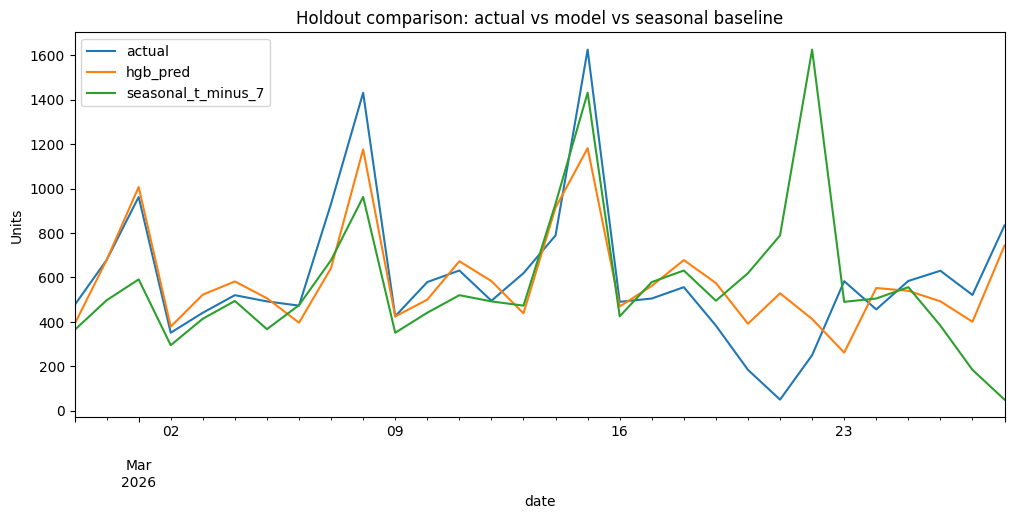

,actual,hgb_pred,naive_t_minus_1,seasonal_t_minus_7
date,,,,
2026-03-19,383,574.7,556.0,495.0
2026-03-20,184,391.5,383.0,619.0
2026-03-21,50,528.4,184.0,789.0
2026-03-22,250,412.8,50.0,1625.0
2026-03-23,583,261.5,250.0,490.0
2026-03-24,456,552.2,583.0,505.0
2026-03-25,584,539.6,456.0,556.0
2026-03-26,630,492.4,584.0,383.0
2026-03-27,521,400.3,630.0,184.0


In [9]:
results = pd.DataFrame({
    "actual": y_test,
    "hgb_pred": np.round(test_pred, 1),
    "naive_t_minus_1": np.round(baseline_frame["naive_t_minus_1"], 1),
    "seasonal_t_minus_7": np.round(baseline_frame["seasonal_t_minus_7"], 1),
}, index=test_df.index)

ax = results[["actual", "hgb_pred", "seasonal_t_minus_7"]].plot(
    title="Holdout comparison: actual vs model vs seasonal baseline"
)
ax.set_ylabel("Units")
plt.show()

results.tail(10)

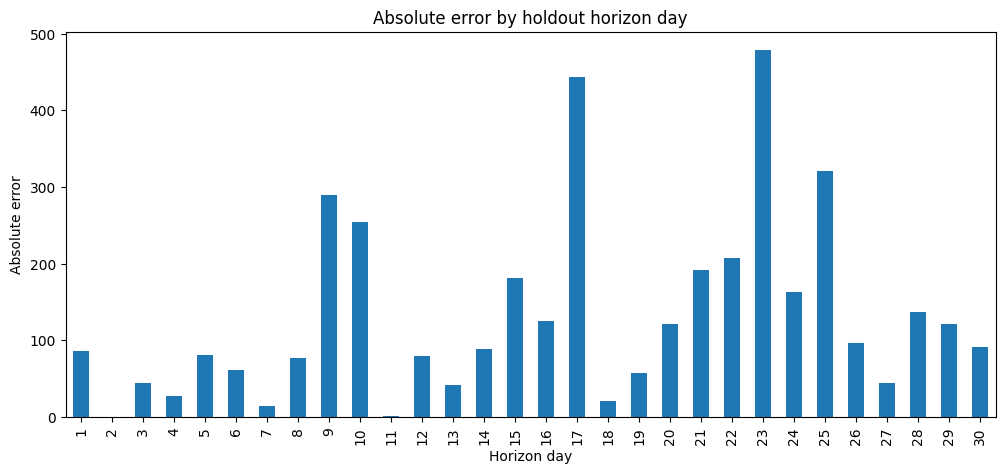

,horizon_day,abs_error
date,,
2026-02-27,1,85.7
2026-02-28,2,0.1
2026-03-01,3,44.8
2026-03-02,4,27.3
2026-03-03,5,81.5
2026-03-04,6,61.8
2026-03-05,7,14.2
2026-03-06,8,76.8
2026-03-07,9,289.8


In [10]:
horizon_diag = results[["actual", "hgb_pred"]].copy()
horizon_diag["horizon_day"] = np.arange(1, len(horizon_diag) + 1)
horizon_diag["abs_error"] = (horizon_diag["actual"] - horizon_diag["hgb_pred"]).abs()

ax = horizon_diag.plot(
    x="horizon_day",
    y="abs_error",
    kind="bar",
    legend=False,
    title="Absolute error by holdout horizon day",
)
ax.set_xlabel("Horizon day")
ax.set_ylabel("Absolute error")
plt.show()

horizon_diag[["horizon_day", "abs_error"]].head(10)

## 5) Forecast the next 14 days 

We train on all available feature rows and recursively forecast:
- point forecast (p50 proxy)
- p10 quantile model
- p90 quantile model

This gives interval-aware planning for shortage risk decisions.

In [14]:
full_X = feature_df[feature_cols]
full_y = feature_df[target]

model_p50 = build_model(loss="squared_error")
model_p10 = build_model(loss="quantile", quantile=0.1)
model_p90 = build_model(loss="quantile", quantile=0.9)

model_p50.fit(full_X, full_y)
model_p10.fit(full_X, full_y)
model_p90.fit(full_X, full_y)


def recursive_forecast_with_intervals(
    history_frame: pd.DataFrame,
    horizon: int,
    feature_columns: list[str],
    model_low,
    model_mid,
    model_high,
) -> pd.DataFrame:
    history = history_frame.copy()
    future_dates = pd.date_range(
        history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D"
    )

    rows = []
    for fdate in future_dates:
        feats = make_features(history)
        last_row = feats.iloc[-1:][feature_columns]

        p10 = float(model_low.predict(last_row)[0])
        p50 = float(model_mid.predict(last_row)[0])
        p90 = float(model_high.predict(last_row)[0])

        p10 = max(0.0, p10)
        p50 = max(0.0, p50)
        p90 = max(0.0, p90)

        lower = min(p10, p50, p90)
        upper = max(p10, p50, p90)
        median = np.clip(p50, lower, upper)

        rows.append({"date": fdate, "p10": lower, "p50": median, "p90": upper})

        history.loc[fdate, "demand_units"] = median

    return pd.DataFrame(rows).set_index("date")


forecast_df = recursive_forecast_with_intervals(
    history_frame=df.set_index("date"),
    horizon=CONFIG["forecast_horizon"],
    feature_columns=feature_cols,
    model_low=model_p10,
    model_mid=model_p50,
    model_high=model_p90,
)

forecast_df.round(1)

,p10,p50,p90
date,,,
2026-03-29,475.6,742.9,914.0
2026-03-30,602.3,990.4,1289.4
2026-03-31,319.1,491.5,699.2
2026-04-01,410.0,687.4,771.6
2026-04-02,450.1,633.5,742.3
2026-04-03,454.3,574.3,749.4
2026-04-04,353.3,449.4,546.2
2026-04-05,536.9,832.9,1044.0
2026-04-06,451.5,851.2,1007.2


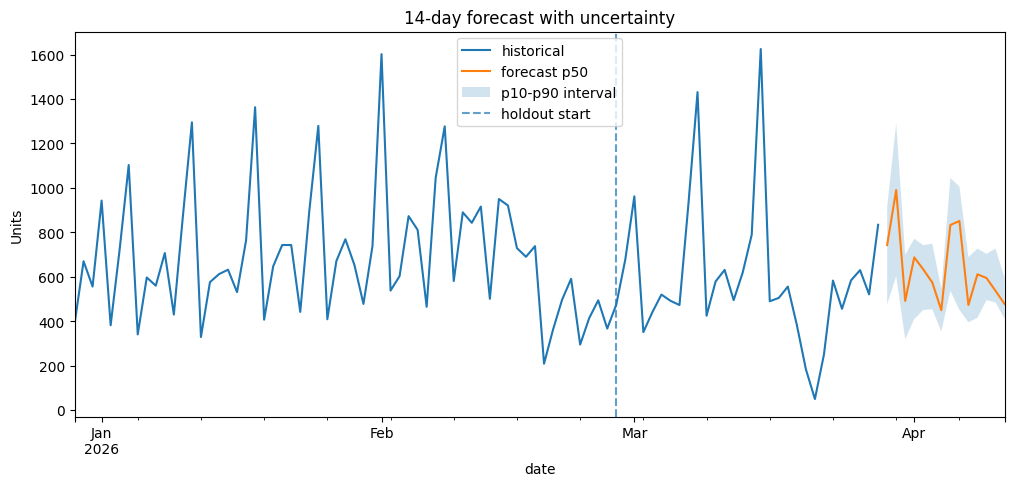

In [15]:
split_date = test_df.index[0]

plot_history = df.set_index("date")["demand_units"].tail(90)
ax = plot_history.plot(label="historical", title="14-day forecast with uncertainty")

forecast_df["p50"].plot(ax=ax, label="forecast p50")
ax.fill_between(
    forecast_df.index,
    forecast_df["p10"],
    forecast_df["p90"],
    alpha=0.2,
    label="p10-p90 interval",
)

ax.axvline(split_date, linestyle="--", alpha=0.7, label="holdout start")
ax.set_ylabel("Units")
ax.legend()
plt.show()

## 6) Turn forecast into risk-aware operational decisions

Point forecasts alone are not enough for supply decisions.

Here we use:
- near-term demand mean (`p50`)
- demand uncertainty from interval width (`p10` / `p90`)
- safety stock based on a service-level target

Output:
- shortage risk probability
- recommended transfer quantity
- urgency label
- day-level ops table for the next 14 days

In [13]:
def normal_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


recent_daily_baseline = float(df["demand_units"].tail(14).median())
current_stock = int(round(recent_daily_baseline * 2.5))
inbound_next_3_days = int(round(recent_daily_baseline * 1.2))

next_3 = forecast_df.iloc[:3].copy()
mu_3 = float(next_3["p50"].sum())

# Approximate sigma from quantiles: p90 - p10 ~= 2.56 * sigma for normal-like errors.
sigma_daily = ((next_3["p90"] - next_3["p10"]) / 2.56).clip(lower=0.5)
sigma_3 = float(np.sqrt((sigma_daily ** 2).sum()))

required_stock_3d = mu_3 + CONFIG["service_level_z"] * sigma_3
available_3d = current_stock + inbound_next_3_days
recommended_transfer = max(0, int(np.ceil(required_stock_3d - available_3d)))

if sigma_3 <= 1e-9:
    shortage_risk_3d = 1.0 if available_3d < mu_3 else 0.0
else:
    z_value = (available_3d - mu_3) / sigma_3
    shortage_risk_3d = 1.0 - normal_cdf(z_value)

if shortage_risk_3d >= 0.60:
    urgency = "high"
elif shortage_risk_3d >= 0.30:
    urgency = "medium"
else:
    urgency = "low"

print(f"Recent daily baseline (median last 14 days): {recent_daily_baseline:.1f}")
print(f"Current stock (auto-scaled): {current_stock}")
print(f"Inbound next 3 days (auto-scaled): {inbound_next_3_days}")
print(f"Expected demand next 3 days (p50): {mu_3:.1f}")
print(f"Demand uncertainty sigma next 3 days: {sigma_3:.2f}")
print(f"Required stock for service target: {required_stock_3d:.1f}")
print(f"Available stock (current + inbound): {available_3d}")
print(f"Shortage risk probability: {shortage_risk_3d:.1%}")
print(f"Recommended transfer qty: {recommended_transfer}")
print(f"Urgency: {urgency}")

ops_table = forecast_df.copy()
ops_table["expected_units"] = ops_table["p50"].round(1)
ops_table["uncertainty_sigma"] = ((ops_table["p90"] - ops_table["p10"]) / 2.56).clip(lower=0.5).round(2)
ops_table["shortage_risk_score"] = (
    (ops_table["expected_units"] - available_3d) / ops_table["uncertainty_sigma"].replace(0, 0.5)
).clip(-5, 5)
ops_table["recommended_transfer_hint"] = np.where(
    ops_table["shortage_risk_score"] > 1,
    "Increase inbound / transfer",
    "Monitor",
)

ops_table[["p10", "expected_units", "p90", "uncertainty_sigma", "recommended_transfer_hint"]].round(1)

Recent daily baseline (median last 14 days): 513.0
Current stock (auto-scaled): 1282
Inbound next 3 days (auto-scaled): 616
Expected demand next 3 days (p50): 2224.7
Demand uncertainty sigma next 3 days: 351.30
Required stock for service target: 2674.4
Available stock (current + inbound): 1898
Shortage risk probability: 82.4%
Recommended transfer qty: 777
Urgency: high


,p10,expected_units,p90,uncertainty_sigma,recommended_transfer_hint
date,,,,,
2026-03-29,475.6,742.9,914.0,171.2,Monitor
2026-03-30,602.3,990.4,1289.4,268.4,Monitor
2026-03-31,319.1,491.5,699.2,148.4,Monitor
2026-04-01,410.0,687.4,771.6,141.2,Monitor
2026-04-02,450.1,633.5,742.3,114.1,Monitor
2026-04-03,454.3,574.3,749.4,115.3,Monitor
2026-04-04,353.3,449.4,546.2,75.3,Monitor
2026-04-05,536.9,832.9,1044.0,198.1,Monitor
2026-04-06,451.5,851.2,1007.2,217.1,Monitor
